In [25]:
# Import libraries
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import yfinance as yf
import warnings
warnings.simplefilter("ignore")
plt.style.use('ggplot')

[*********************100%***********************]  1 of 1 completed

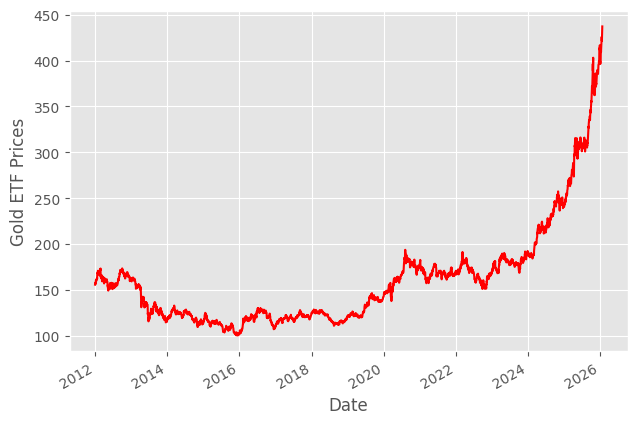

In [26]:
# Read data
Df = yf.download('GLD', '2012-01-01', '2026-01-21', auto_adjust=True)
if isinstance(Df.columns, pd.MultiIndex):
    Df.columns = Df.columns.droplevel(1)
# Only keep close columns
Df = Df[['Close']]
# Drop rows with missing values
Df = Df.dropna()
# Plot the closing price of GLD
Df.Close.plot(figsize=(7.2, 5), color='r')

plt.ylabel("Gold ETF Prices")
plt.show()

In [27]:
# Define explanatory variables
Df['S_3'] = Df['Close'].rolling(window=3).mean()
Df['S_9'] = Df['Close'].rolling(window=9).mean()
Df['next_day_price'] = Df['Close'].shift(-1)

Df = Df.dropna()
X = Df[['S_3', 'S_9']]

# Define dependent variable
y = Df['next_day_price']

In [28]:
# ==================== DATA TABLE VISUALIZATION ====================
import matplotlib.pyplot as plt
from IPython.display import display

# Shape and info
print(f"\n Shape: {Df.shape[0]} rows × {Df.shape[1]} columns")
print(f" Date Range: {Df.index[0].date()}  →  {Df.index[-1].date()}")

# Display first 10 rows with styling
print("\n First 10 Rows (Processed Data):")
display(
    Df.head(10).style
    .format({
        'Close':             '${:.4f}',
        'S_3':               '${:.4f}',
        'S_9':               '${:.4f}',
        'next_day_price':    '${:.4f}'
    })
    .background_gradient(subset=['Close'], cmap='YlOrRd')
    .background_gradient(subset=['S_3'],   cmap='Blues')
    .background_gradient(subset=['S_9'],   cmap='Greens')
    .set_caption("GLD ETF — Feature-Engineered Dataset (first 10 rows)")
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '14px'), ('font-weight', 'bold'), ('color', '#333')]
    }])
)

# Display last 10 rows
print("\n Last 10 Rows (Most Recent Data):")
display(
    Df.tail(10).style
    .format({
        'Close':             '${:.4f}',
        'S_3':               '${:.4f}',
        'S_9':               '${:.4f}',
        'next_day_price':    '${:.4f}'
    })
    .background_gradient(subset=['Close'], cmap='YlOrRd')
    .background_gradient(subset=['S_3'],   cmap='Blues')
    .background_gradient(subset=['S_9'],   cmap='Greens')
    .set_caption("GLD ETF — Feature-Engineered Dataset (last 10 rows)")
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '14px'), ('font-weight', 'bold'), ('color', '#333')]
    }])
)

# Statistical summary
print("\n Statistical Summary:")
display(
    Df.describe().style
    .format('${:.4f}')
    .background_gradient(cmap='coolwarm', axis=0)
    .set_caption("Descriptive Statistics")
)

# Missing values check
print("\n Missing Values:")
missing = Df.isnull().sum()
print(missing.to_string())
print(f"\n Total missing values: {missing.sum()}")

# Column descriptions
# print("\n📋 Column Descriptions:")
col_desc = {
    'Close':          'Daily closing price of GLD ETF ($)',
    'S_3':            f'3-day rolling mean of Close (short MA)',
    'S_9':            f'9-day rolling mean of Close (long MA)',
    'next_day_price': 'Target — next day closing price (shifted by 1)'
}
for col, desc in col_desc.items():
    print(f"  {col:<20} → {desc}")



 Shape: 3523 rows × 4 columns
 Date Range: 2012-01-13  →  2026-01-16

 First 10 Rows (Processed Data):


Price,Close,S_3,S_9,next_day_price
Date,,,,
2012-01-13 00:00:00,$159.2600,$159.7700,$158.0067,$160.5000
2012-01-17 00:00:00,$160.5000,$160.0467,$158.5156,$161.6000
2012-01-18 00:00:00,$161.6000,$160.4533,$159.0589,$161.2200
2012-01-19 00:00:00,$161.2200,$161.1067,$159.4411,$162.0700
2012-01-20 00:00:00,$162.0700,$161.6300,$159.9822,$163.1600
2012-01-23 00:00:00,$163.1600,$162.1500,$160.7222,$162.0100
2012-01-24 00:00:00,$162.0100,$162.4133,$161.0967,$166.4200
2012-01-25 00:00:00,$166.4200,$163.8633,$161.8467,$167.2700
2012-01-26 00:00:00,$167.2700,$165.2333,$162.6122,$168.9700



 Last 10 Rows (Most Recent Data):


Price,Close,S_3,S_9,next_day_price
Date,,,,
2026-01-05 00:00:00,$408.7600,$401.1167,$405.7089,$413.1800
2026-01-06 00:00:00,$413.1800,$406.7400,$406.2589,$409.2300
2026-01-07 00:00:00,$409.2300,$410.3900,$405.7689,$411.4900
2026-01-08 00:00:00,$411.4900,$411.3000,$405.7200,$414.4700
2026-01-09 00:00:00,$414.4700,$411.7300,$405.4678,$422.2300
2026-01-12 00:00:00,$422.2300,$416.0633,$408.0933,$421.6300
2026-01-13 00:00:00,$421.6300,$419.4433,$410.6200,$425.9400
2026-01-14 00:00:00,$425.9400,$423.2667,$413.9122,$423.3300
2026-01-15 00:00:00,$423.3300,$423.6333,$416.6956,$421.2900



 Statistical Summary:


Price,Close,S_3,S_9,next_day_price
count,$3523.0000,$3523.0000,$3523.0000,$3523.0000
mean,$161.0249,$160.9506,$160.7267,$161.1038
std,$56.7931,$56.6098,$56.0696,$56.9834
min,$100.5000,$101.5767,$102.0722,$100.5000
25%,$121.3450,$121.4417,$121.4289,$121.3450
50%,$152.0800,$152.2967,$152.8389,$152.0800
75%,$175.3600,$175.3933,$175.3228,$175.3950
max,$425.9400,$423.6333,$418.0878,$437.2300



 Missing Values:
Price
Close             0
S_3               0
S_9               0
next_day_price    0

 Total missing values: 0
  Close                → Daily closing price of GLD ETF ($)
  S_3                  → 3-day rolling mean of Close (short MA)
  S_9                  → 9-day rolling mean of Close (long MA)
  next_day_price       → Target — next day closing price (shifted by 1)


In [29]:
# Cointegration testing
S_3 = Df['S_3'].dropna()
S_9 = Df['S_9'].dropna()

# Since S_3 and S_9 are moving averages, we could check their cointegration with the original Close series
close_price = Df['next_day_price']

# Conduct Engle-Granger Cointegration Test between S_3 and Close price
coint_result_3 = coint(S_3, close_price)

# Conduct Engle-Granger Cointegration Test between S_9 and Close price
coint_result_9 = coint(S_9, close_price)

# Extract p-values
p_value_3 = coint_result_3[1]
p_value_9 = coint_result_9[1]

# Print the results
print(f"Cointegration p-value between S_3 and next_day_price: {p_value_3}")
print(f"Cointegration p-value between S_9 and next_day_price: {p_value_9}")

# Interpretation
alpha = 0.05
if p_value_3 < alpha:
    print("S_3 and next_day_price are cointegrated.")
else:
    print("S_3 and next_day_price are not cointegrated.")

if p_value_9 < alpha:
    print("S_9 and next_day_price are cointegrated.")
else:
    print("S_9 and next_day_price are not cointegrated.")

Cointegration p-value between S_3 and next_day_price: 3.1342217460750485e-16
Cointegration p-value between S_9 and next_day_price: 1.2680495744873625e-15
S_3 and next_day_price are cointegrated.
S_9 and next_day_price are cointegrated.


In [30]:
# Split the data into train and test dataset
t = .8
t = int(t*len(Df))

# Train dataset
X_train = X[:t]
y_train = y[:t]

# Test dataset
X_test = X[t:]
y_test = y[t:]

# Create a linear regression model
linear = LinearRegression().fit(X_train, y_train)
print("Linear Regression model")
print("Gold ETF Price (y) = %.2f * 3 Days Moving Average (x1) \
+ %.2f * 9 Days Moving Average (x2) \
+ %.2f (constant)" % (linear.coef_[0], linear.coef_[1], linear.intercept_))

Linear Regression model
Gold ETF Price (y) = 1.19 * 3 Days Moving Average (x1) + -0.19 * 9 Days Moving Average (x2) + 0.28 (constant)


In [31]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

Df['S_3_norm'] = Df['S_3'] / Df['Close']
Df['S_9_norm'] = Df['S_9'] / Df['Close']

Df['target_ratio'] = Df['next_day_price'] / Df['Close']

X_raw   = Df[['S_3', 'S_9']]                    # for Linear Regression
X_norm  = Df[['S_3_norm', 'S_9_norm']]           # for XGBoost / Random Forest

y_price = Df['next_day_price']                   # absolute price target (LR)
y_ratio = Df['target_ratio']                     # ratio target (tree models)

# Train/test split (80/20)
t = int(0.8 * len(Df))

X_raw_train,  X_raw_test  = X_raw[:t],  X_raw[t:]
X_norm_train, X_norm_test = X_norm[:t], X_norm[t:]
y_price_train, y_price_test = y_price[:t], y_price[t:]
y_ratio_train, y_ratio_test = y_ratio[:t], y_ratio[t:]

test_close  = Df['Close'].iloc[t:].values
test_prices = y_price_test.values   # actual next-day prices ($)

linear = LinearRegression().fit(X_raw_train, y_price_train)
lr_pred = linear.predict(X_raw_test)

# ---------- XGBoost ----------
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    verbosity=0
).fit(X_norm_train, y_ratio_train,
      eval_set=[(X_norm_test, y_ratio_test)],
      verbose=False)

xgb_ratio_pred = xgb_model.predict(X_norm_test)
xgb_pred       = xgb_ratio_pred * test_close    # ratio → absolute price

# ---------- Random Forest ----------
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
).fit(X_norm_train, y_ratio_train)

rf_ratio_pred = rf_model.predict(X_norm_test)
rf_pred       = rf_ratio_pred * test_close      # ratio → absolute price

print(" All three models trained successfully.")
print(f"   Test set size : {len(test_prices)} days")
print(f"   Price range   : ${test_prices.min():.2f}  –  ${test_prices.max():.2f}")


 All three models trained successfully.
   Test set size : 705 days
   Price range   : $168.83  –  $437.23


In [ ]:
# MODEL PERFORMANCE COMPARISON (Test Set)

def compute_metrics(y_true, y_pred, label):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'Model': label, 'R² (%)': round(r2*100, 2),
            'MAE ($)': round(mae, 4), 'RMSE ($)': round(rmse, 4),
            'MAPE (%)': round(mape, 4)}

metrics_df = pd.DataFrame([
    compute_metrics(test_prices, lr_pred,  'Linear Regression'),
    compute_metrics(test_prices, xgb_pred, 'XGBoost'),
    compute_metrics(test_prices, rf_pred,  'Random Forest'),
])

display(
    metrics_df.set_index('Model').style
    .format({'R² (%)': '{:.2f}', 'MAE ($)': '{:.4f}',
             'RMSE ($)': '{:.4f}', 'MAPE (%)': '{:.4f}'})
    .background_gradient(subset=['R² (%)'],   cmap='Greens')
    .background_gradient(subset=['MAE ($)'],  cmap='Reds_r')
    .background_gradient(subset=['RMSE ($)'], cmap='Reds_r')
    .background_gradient(subset=['MAPE (%)'], cmap='Reds_r')
    .set_caption("Higher R² = better │ Lower MAE/RMSE/MAPE = better")
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '13px'), ('font-weight', 'bold')]
    }])
)

TypeError: 'float' object is not callable

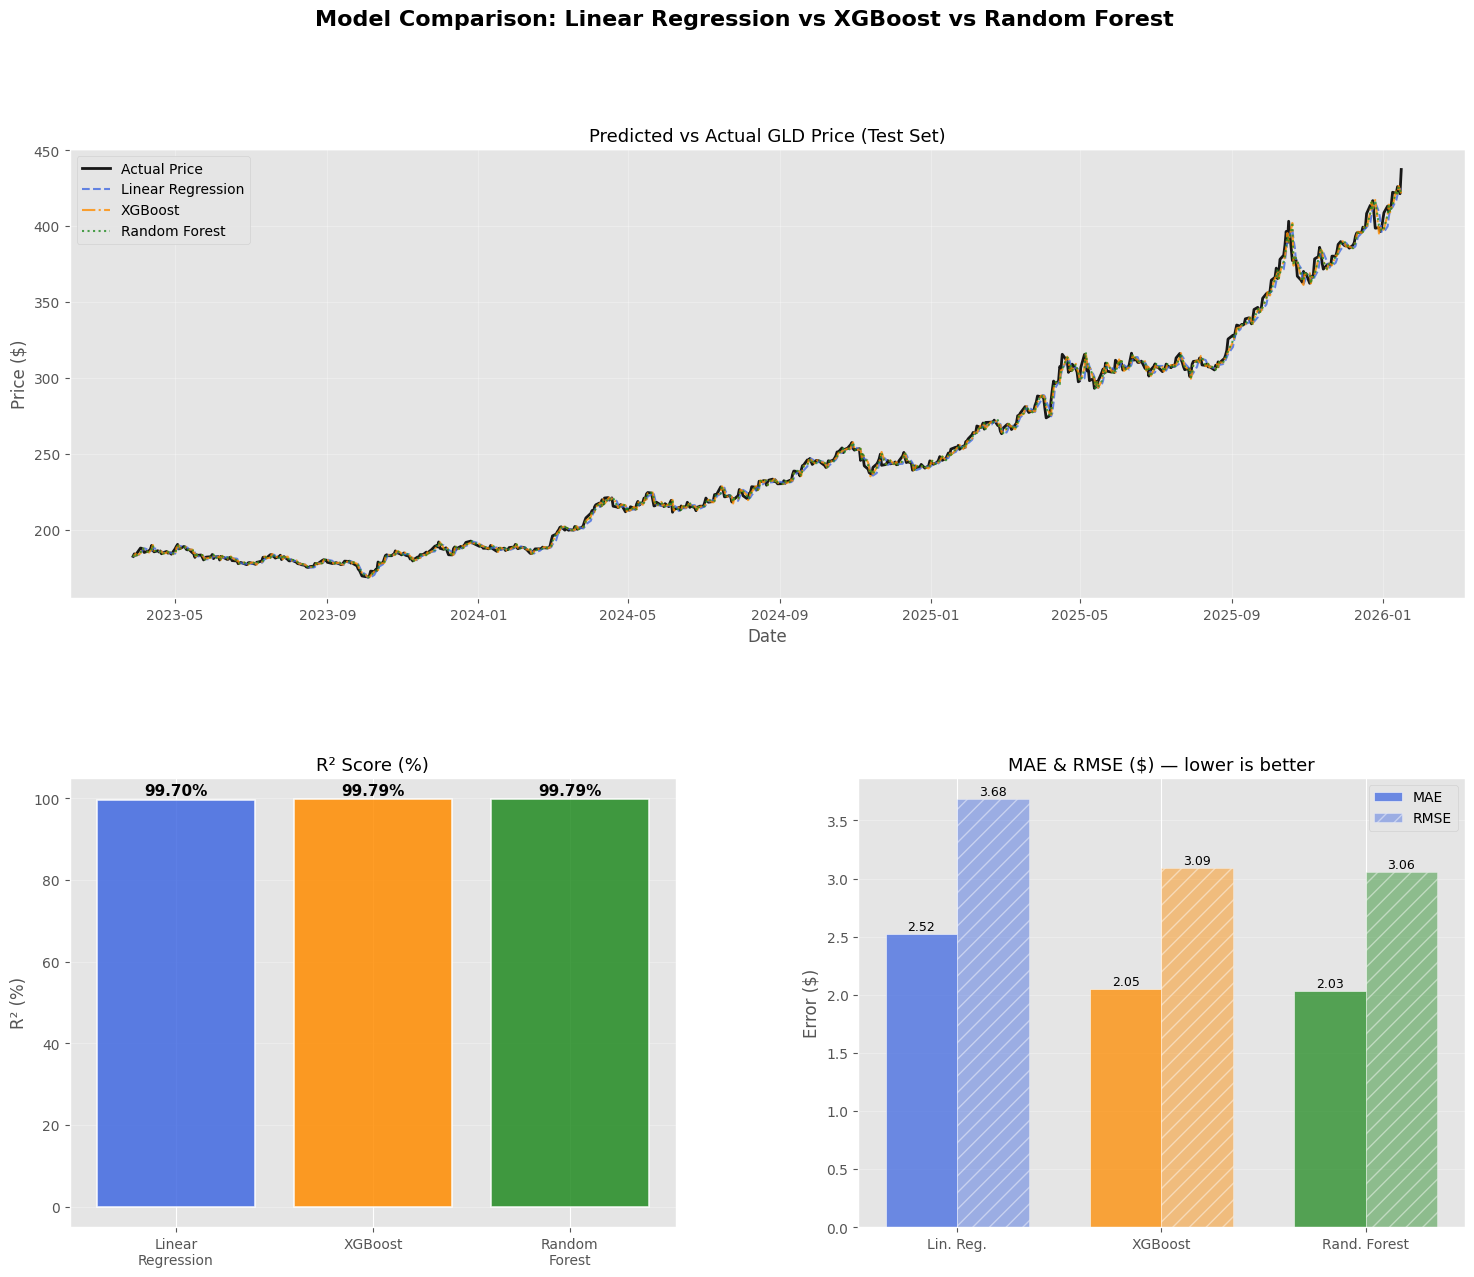

📊 Chart saved as model_comparison.png


In [ ]:
# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

test_dates = Df.index[t:]

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Model Comparison: Linear Regression vs XGBoost vs Random Forest',
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# ── Chart 1: Predicted vs Actual Prices ─────────────────────────
ax1 = fig.add_subplot(gs[0, :])   # full top row
ax1.plot(test_dates, test_prices, color='black',  lw=2,   label='Actual Price',         alpha=0.9)
ax1.plot(test_dates, lr_pred,     color='royalblue', lw=1.5, linestyle='--', label='Linear Regression', alpha=0.8)
ax1.plot(test_dates, xgb_pred,    color='darkorange', lw=1.5, linestyle='-.',label='XGBoost',           alpha=0.8)
ax1.plot(test_dates, rf_pred,     color='forestgreen', lw=1.5, linestyle=':',label='Random Forest',     alpha=0.8)
ax1.set_title('Predicted vs Actual GLD Price (Test Set)', fontsize=13)
ax1.set_xlabel('Date');  ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left');  ax1.grid(True, alpha=0.3)

# ── Chart 2: R² Bar Chart ────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
models  = ['Linear\nRegression', 'XGBoost', 'Random\nForest']
r2_vals = [
    r2_score(test_prices, lr_pred)  * 100,
    r2_score(test_prices, xgb_pred) * 100,
    r2_score(test_prices, rf_pred)  * 100,
]
colors = ['royalblue', 'darkorange', 'forestgreen']
bars = ax2.bar(models, r2_vals, color=colors, alpha=0.85, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, r2_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.set_title('R² Score (%)', fontsize=13);  ax2.set_ylabel('R² (%)')
ax2.set_ylim(min(0, min(r2_vals)) - 5, 105);  ax2.grid(axis='y', alpha=0.3)

# ── Chart 3: MAE & RMSE Grouped Bar ─────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
mae_vals  = [mean_absolute_error(test_prices, p)              for p in [lr_pred, xgb_pred, rf_pred]]
rmse_vals = [np.sqrt(mean_squared_error(test_prices, p))      for p in [lr_pred, xgb_pred, rf_pred]]
x = np.arange(len(models))
w = 0.35
b1 = ax3.bar(x - w/2, mae_vals,  w, label='MAE',  color=colors, alpha=0.75, edgecolor='white')
b2 = ax3.bar(x + w/2, rmse_vals, w, label='RMSE', color=colors, alpha=0.45, edgecolor='white', hatch='//')
for bar, val in zip(list(b1)+list(b2), mae_vals+rmse_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)
ax3.set_xticks(x);  ax3.set_xticklabels(['Lin. Reg.', 'XGBoost', 'Rand. Forest'])
ax3.set_title('MAE & RMSE ($) — lower is better', fontsize=13)
ax3.set_ylabel('Error ($)');  ax3.legend();  ax3.grid(axis='y', alpha=0.3)

plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved as model_comparison.png")

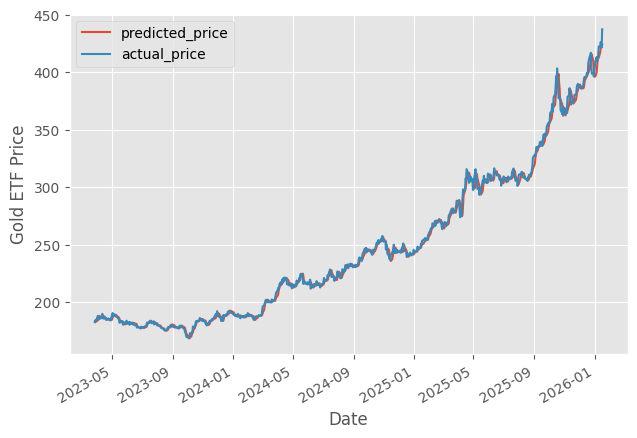

R-squared: 99.7%


In [34]:
# Predicting the Gold ETF prices
predicted_price = linear.predict(X_test)
predicted_price = pd.DataFrame(
    predicted_price, index=y_test.index, columns=['price'])

predicted_price.plot(figsize=(7.2, 5))
y_test.plot()
plt.legend(['predicted_price', 'actual_price'])
plt.ylabel("Gold ETF Price")
plt.show()

# R square
r2_score = linear.score(X[t:], y[t:])*100
print(f"R-squared: {float('{0:.2f}'.format(r2_score))}%")

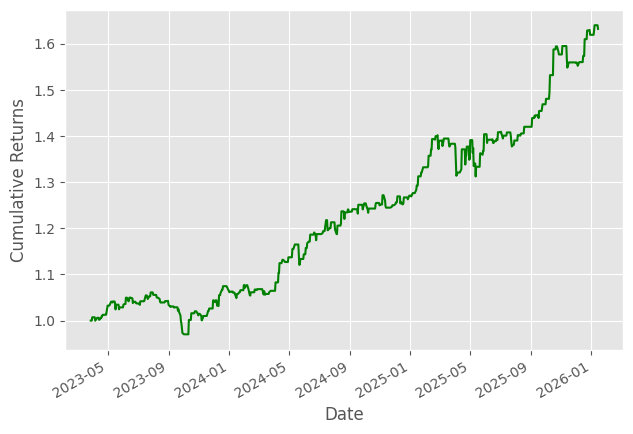

Sharpe Ratio 1.82


In [35]:
# Calculate cumulative returns
gold = pd.DataFrame()

gold['price'] = Df[t:]['Close']
gold['predicted_price_next_day'] = predicted_price
gold['actual_price_next_day'] = y_test
gold['gold_returns'] = gold['price'].pct_change().shift(-1)

gold['signal'] = np.where(gold.price < gold.predicted_price_next_day,1,0)

gold['strategy_returns'] = gold.signal * gold['gold_returns']
((gold['strategy_returns']+1).cumprod()).plot(figsize=(7.2, 5), color='g')
plt.ylabel('Cumulative Returns')
plt.show()

# Calculate sharpe ratio
sharpe = gold['strategy_returns'].mean()/gold['strategy_returns'].std()*(252**0.5)
print('Sharpe Ratio %.2f' % (sharpe))


In [36]:
# Signal generation for daily moves
import datetime as dt
current_date = dt.datetime.now()

# Get the data
data = yf.download('GLD', '2012-01-01', '2026-01-21', auto_adjust=True)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

data['S_3'] = data['Close'].rolling(window=3).mean()
data['S_9'] = data['Close'].rolling(window=9).mean()
data = data.dropna()

# Forecast the price
data['predicted_gold_price'] = linear.predict(data[['S_3', 'S_9']])
data['signal'] = np.where(data.Close < data.predicted_gold_price,"Buy","No Position")

[*********************100%***********************]  1 of 1 completed


In [37]:
# Print the forecast
print("Latest Signal and Prediction:")
data.tail(1)[['Close','signal','predicted_gold_price']].T

Latest Signal and Prediction:


Date,2026-01-20
Price,
Close,437.230011
signal,No Position
predicted_gold_price,427.961362
